In [43]:
import os
import json
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

repo = 'C:\\Users\\possi\\OneDrive - University of Strathclyde\\uofg\\data\\CChandler_thesis_data\\case_study_1\\playground'

# Load data from repo

In [44]:
df_01 = pd.read_csv(repo+'/01/01model_check.csv', header=[0], index_col=[0])
df_11 = pd.read_csv(repo+'/11/11model_check.csv', header=[0], index_col=[0])

df_01['run'] = 0
df_11['run'] = 1

df_mc = pd.concat([df_01, df_11])
print(df_mc.head())
print(df_mc.shape)

   stack_size  set_size  state_size  n_states  adj_list_compile  \
0           5        15           4        15               184   
1           5        15           4        15               184   
2           5        15           4        15               184   
3           5         7           4        15               184   
4           4         4           4        15               184   

   stack_compile  set_compile  run  
0             12           24    0  
1             12           24    0  
2             12           24    0  
3             12           24    0  
4             12           24    0  
(100, 8)


In [45]:
df_usage_01 = pd.read_csv(repo+'/01/01usage.csv', header=[0], index_col=[0])
df_usage_02 = pd.read_csv(repo+'/02/02usage.csv', header=[0], index_col=[0])
df_usage_11 = pd.read_csv(repo+'/11/11usage.csv', header=[0], index_col=[0])
df_usage_12 = pd.read_csv(repo+'/12/12usage.csv', header=[0], index_col=[0])

df_usage_01['run'] = 0
df_usage_01['method'] = 'multi'
df_usage_02['run'] = 0
df_usage_02['method'] = 'single'

df_usage_11['run'] = 1
df_usage_11['method'] = 'multi'
df_usage_12['run'] = 1
df_usage_12['method'] = 'single'

df_usage = pd.concat([df_usage_01, df_usage_02, df_usage_11, df_usage_12])
print(df_usage.head())

     pr   ni     virt     res     shr status  cpu_perc  mem_perc  cpu_time  \
0  20.0  0.0  37536.0  3528.0  2904.0      S       6.7       0.4      0.58   
1  20.0  0.0  37536.0  3528.0  2904.0      S       0.0       0.4      0.58   
2  20.0  0.0  37536.0  3528.0  2904.0      S       0.0       0.4      0.58   
3  20.0  0.0  37536.0  3528.0  2904.0      S       0.0       0.4      0.58   
4  20.0  0.0  37536.0  3528.0  2904.0      S       0.0       0.4      0.58   

   mem_total  mem_free  mem_used  cache  swap_total  swap_free  swap_used  \
0      922.0     642.0      81.5  197.0       100.0      100.0        0.0   
1      922.0     642.0      81.5  197.0       100.0      100.0        0.0   
2      922.0     642.0      81.5  197.0       100.0      100.0        0.0   
3      922.0     642.0      81.5  197.0       100.0      100.0        0.0   
4      922.0     642.0      81.5  197.0       100.0      100.0        0.0   

   process_uptime  run method  
0           0.000    0  multi  
1   

In [46]:
df_plan_01 = pd.read_csv(repo+'/01/01plan.csv', header=[0], index_col=[0])
df_plan_11 = pd.read_csv(repo+'/11/11plan.csv', header=[0], index_col=[0])

df_plan_01['run'] = 0
df_plan_11['run'] = 1

df_plan = pd.concat([df_plan_01, df_plan_11])
df_mc['steps'] = df_plan.steps.values
print(df_plan.head())

  accept     path                                  plan  latency  steps  run
0      3      0 1                       left -> default    8.841      2    0
1      3      0 1                       left -> default    7.212      2    0
2      4      0 2                      right -> default    4.395      2    0
3   8 12  0 2 4 6  right -> straight -> left -> default    5.864      4    0
4     11  0 1 3 9   left -> straight -> left -> default   14.022      4    0


# Plan execution and processing latency

### Number of plans

In [47]:
df_plan[df_plan.run == 0].count()

accept     50
path       50
plan       50
latency    54
steps      54
run        54
dtype: int64

In [48]:
df_plan = df_plan[df_plan.steps != 0]
df_plan[df_plan.run == 0].count()

accept     50
path       50
plan       50
latency    50
steps      50
run        50
dtype: int64

In [49]:
df_plan[df_plan.run == 1].count()

accept     46
path       46
plan       46
latency    46
steps      46
run        46
dtype: int64

### Comparison of steps

<Axes: xlabel='run', ylabel='count'>

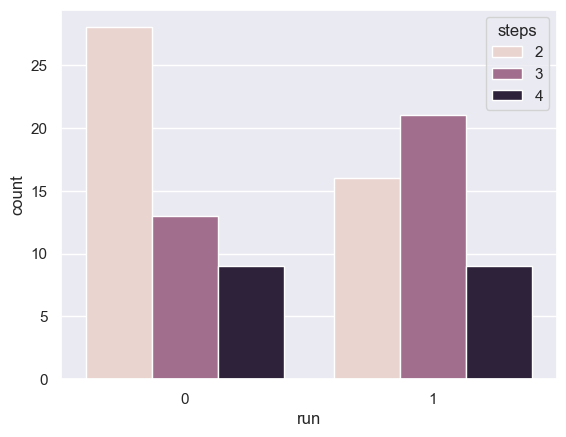

In [50]:
sns.countplot(df_plan.dropna(axis=0), x='run', hue='steps')

In [54]:
print(f'N of 2-step plans: {len(df_plan[df_plan.steps == 2])}')
print(f'N of 3-step plans: {len(df_plan[df_plan.steps == 3])}')
print(f'N of 4-step plans: {len(df_plan[df_plan.steps == 4])}')

N of 2-step plans: 44
N of 3-step plans: 34
N of 4-step plans: 18


<Axes: xlabel='steps', ylabel='count'>

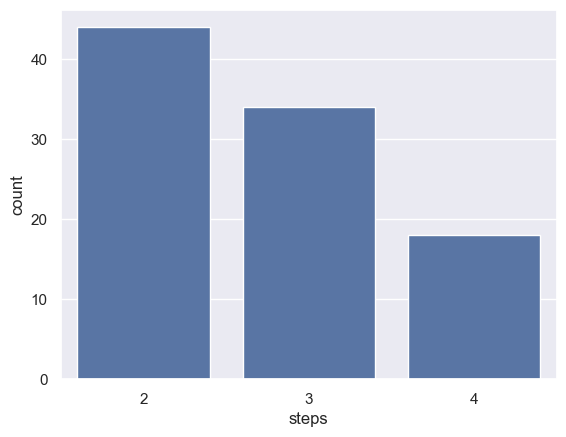

In [55]:
sns.countplot(df_plan.dropna(axis=0), x='steps')

### Comparison of processing latency

<Axes: xlabel='run', ylabel='latency'>

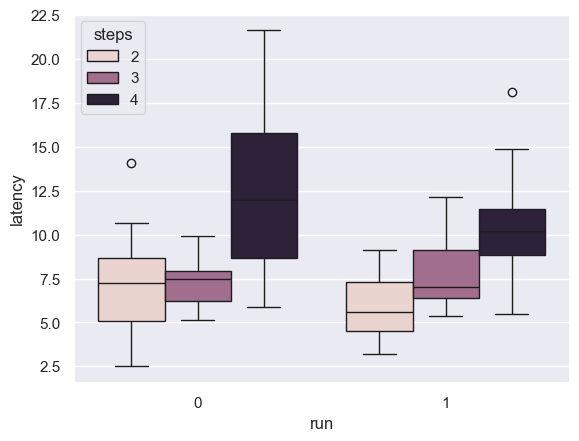

In [56]:
sns.boxplot(df_plan.dropna(axis=0), x='run', y='latency', hue='steps')

In [61]:
df_plan[df_plan.steps == 2].dropna(axis=0).latency.describe()

count    44.000000
mean      6.601795
std       2.495903
min       2.497000
25%       4.644250
50%       6.294500
75%       8.400000
max      14.092000
Name: latency, dtype: float64

In [62]:
df_plan[df_plan.steps == 3].dropna(axis=0).latency.describe()

count    34.000000
mean      7.569529
std       1.790372
min       5.124000
25%       6.340500
50%       7.096000
75%       8.651500
max      12.150000
Name: latency, dtype: float64

In [63]:
df_plan[df_plan.steps == 4].dropna(axis=0).latency.describe()

count    18.000000
mean     11.490778
std       4.666868
min       5.456000
25%       8.701750
50%      10.239500
75%      14.651250
max      21.618000
Name: latency, dtype: float64

<Axes: xlabel='steps', ylabel='latency'>

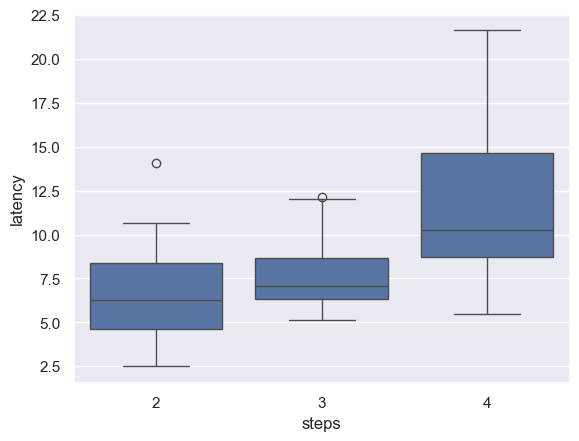

In [64]:
sns.boxplot(df_plan.dropna(axis=0), x='steps', y='latency')

ConfidenceInterval(low=np.float64(5.913522909449074), high=np.float64(7.375613636363636))


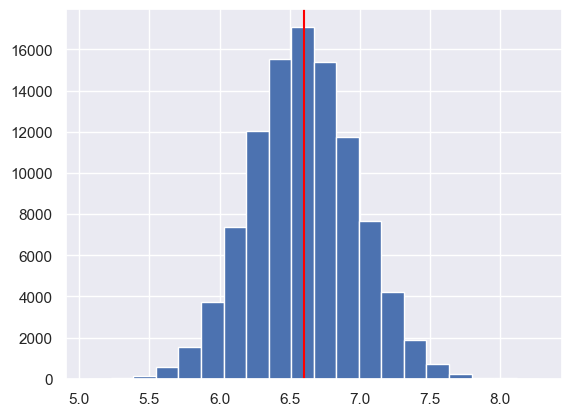

In [65]:
result = stats.bootstrap((df_plan[df_plan.steps == 2].latency, ), 
                          statistic=np.mean, 
                          n_resamples=100000,
                          confidence_level=0.95)

reference = df_plan[df_plan.steps == 2].latency.mean()
plt.hist(result.bootstrap_distribution, bins=20)
plt.axvline(reference, color='red')
print(result.confidence_interval)

ConfidenceInterval(low=np.float64(7.033647058823529), high=np.float64(8.237853744736793))


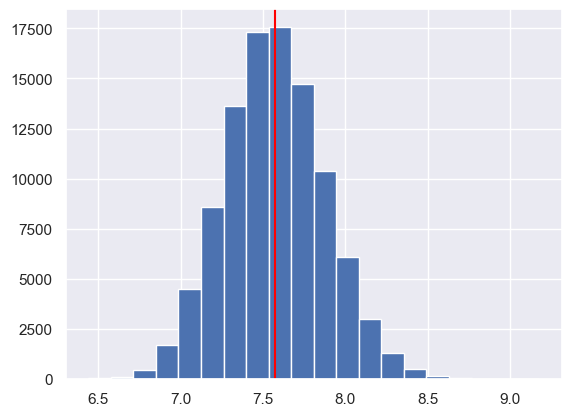

In [66]:
result = stats.bootstrap((df_plan[df_plan.steps == 3].latency, ), 
                          statistic=np.mean, 
                          n_resamples=100000,
                          confidence_level=0.95)

reference = df_plan[df_plan.steps == 3].latency.mean()
plt.hist(result.bootstrap_distribution, bins=20)
plt.axvline(reference, color='red')
print(result.confidence_interval)

ConfidenceInterval(low=np.float64(9.610049867798107), high=np.float64(13.850373503189266))


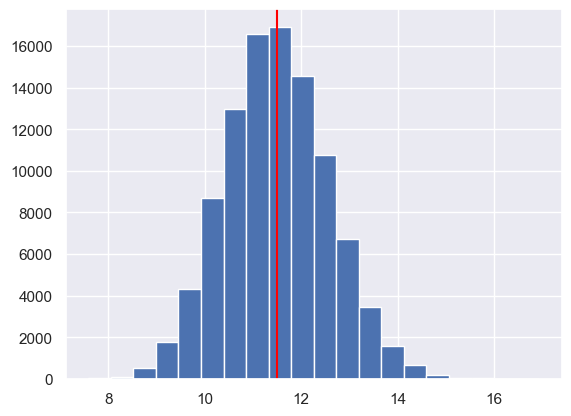

In [67]:
result = stats.bootstrap((df_plan[df_plan.steps == 4].latency, ), 
                          statistic=np.mean, 
                          n_resamples=100000,
                          confidence_level=0.95)

reference = df_plan[df_plan.steps == 4].latency.mean()
plt.hist(result.bootstrap_distribution, bins=20)
plt.axvline(reference, color='red')
print(result.confidence_interval)

# Model checking memory usage

In [68]:
print(df_mc.head())

   stack_size  set_size  state_size  n_states  adj_list_compile  \
0           5        15           4        15               184   
1           5        15           4        15               184   
2           5        15           4        15               184   
3           5         7           4        15               184   
4           4         4           4        15               184   

   stack_compile  set_compile  run  steps  
0             12           24    0      2  
1             12           24    0      2  
2             12           24    0      2  
3             12           24    0      4  
4             12           24    0      4  


In [73]:
result = ((df_mc.stack_size * df_mc.state_size) + \
(df_mc.set_size * df_mc.state_size) + \
(df_mc.n_states * df_mc.state_size) + \
df_mc.adj_list_compile + df_mc.set_compile + df_mc.stack_compile)

print('Worst case model checking memory usage: {} bytes'.format(result.max()))

Worst case model checking memory usage: 360 bytes


# Process memory usage

In [80]:
(df_usage[df_usage.method == 'multi'].res - df_usage[df_usage.method == 'multi'].shr).max(), df_usage[df_usage.method == 'multi'].res.max() / 1024

(1088.0, 4.09375)

In [81]:
(df_usage[df_usage.method == 'single'].res - df_usage[df_usage.method == 'single'].shr).max(), df_usage[df_usage.method == 'single'].res.max() / 1024

(900.0, 3.828125)